## 系統誤差

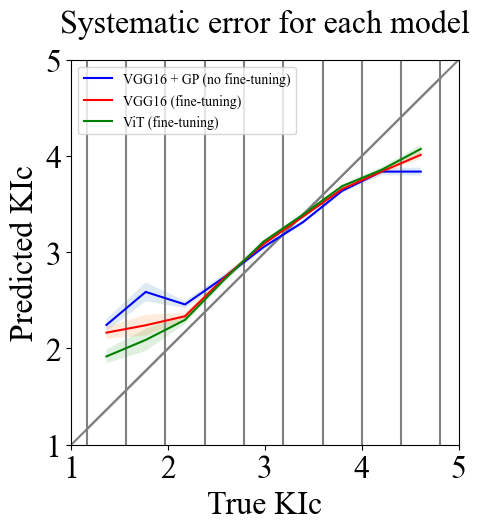

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import japanize_matplotlib
from matplotlib import font_manager as fm
import pandas as pd
import pickle as pkl

# フォントファイルのパスを指定
font_path = './Times New Roman.ttf'  # ここにTimes New Romanのフォントファイルのパスを入力
font_prop = fm.FontProperties(fname=font_path)

## vgg
vgg_oof = pd.read_csv('./KIc/Model/vgg/vgg16_Kfold_seed42_oof_df.csv')
true_kic = vgg_oof['KIc']  
predicted_kic = vgg_oof['preds'] 

## vit
vit_oof = pd.read_csv('./KIc/Model/vit/vit_large_patch32_224_Kfold_seed42_noaug_oof_df.csv')
true_kic_vit = vit_oof['KIc']  
predicted_kic_vit = vit_oof['preds']  

## vgg+GP
f = open("./Mototake_Analysis/VGG+GP/Y_pred_rational_seed42.pkl","rb")
plot_Y_rational42 = pkl.load(f)
f.close() 
true_kic_vgg_gau = pd.Series(plot_Y_rational42[0][3])  
predicted_kic_vgg_gau = pd.Series(plot_Y_rational42[1][3])  
      
# 区切りの数
num_bins = 9

# 区切りの幅を計算
bin_width = (np.max(true_kic) - np.min(true_kic)) / num_bins

# 区切りごとにPredicted KICの平均値を計算
bin_centers = []
predicted_kic_means = []
predicted_kic_means_vit = []
predicted_kic_means_vgg_gau = []
predicted_kic_std = []
predicted_kic_std_vit = []
predicted_kic_std_vgg_gau = []

# plt.rcParams['figure.figsize'] = 17,5
# plt.rcParams["font.size"] = 23
plt.rc('legend', fontsize=10)
plt.figure(figsize=(5, 5))

for i in range(num_bins):
    bin_lower = np.min(true_kic) + i * bin_width
    bin_upper = bin_lower + bin_width
    plt.vlines(bin_lower, 1, 5, colors="gray")
    
    bin_mask = (true_kic >= bin_lower) & (true_kic < bin_upper)
    bin_true_kic = true_kic[bin_mask]
    bin_predicted_kic = predicted_kic[bin_mask]
    bin_centers.append((bin_lower + bin_upper) / 2)
    predicted_kic_means.append(np.mean(bin_predicted_kic))
    predicted_kic_std.append(bin_predicted_kic.std(ddof=0) / np.sqrt(len(bin_predicted_kic)))
    
    bin_mask_vit = (true_kic_vit >= bin_lower) & (true_kic_vit < bin_upper)
    bin_true_kic_vit = true_kic_vit[bin_mask_vit]
    bin_predicted_kic_vit = predicted_kic_vit[bin_mask_vit]
    predicted_kic_means_vit.append(np.mean(bin_predicted_kic_vit))
    predicted_kic_std_vit.append(bin_predicted_kic_vit.std(ddof=0) / \
                                 np.sqrt(len(bin_predicted_kic_vit)))
    
    bin_mask_vgg_gau = (true_kic_vgg_gau >= bin_lower) & (true_kic_vgg_gau < bin_upper)
    bin_true_kic_vgg_gau = true_kic_vgg_gau[bin_mask_vgg_gau]
    bin_predicted_kic_vgg_gau = predicted_kic_vgg_gau[bin_mask_vgg_gau]
    predicted_kic_means_vgg_gau.append(np.mean(bin_predicted_kic_vgg_gau))
    predicted_kic_std_vgg_gau.append(bin_predicted_kic_vgg_gau.std(ddof=0) / \
                                     np.sqrt(len(bin_predicted_kic_vgg_gau)))

plt.vlines(bin_upper, 1, 5, colors="gray")
plt.plot([np.min(true_kic), np.max(true_kic)], [np.min(true_kic), np.max(true_kic)], "-", c="gray")
plt.plot([1,5],[1,5],"-",c="gray")
plt.plot(bin_centers, predicted_kic_means_vgg_gau, 'b-', label='VGG16 + GP (no fine-tuning)')
plt.fill_between(bin_centers, 
                 predicted_kic_means_vgg_gau+np.array(predicted_kic_std_vgg_gau), 
                 predicted_kic_means_vgg_gau-np.array(predicted_kic_std_vgg_gau), 
                 alpha=0.15)
plt.plot(bin_centers, predicted_kic_means, 'r-', label='VGG16 (fine-tuning)')
plt.fill_between(bin_centers, 
                 predicted_kic_means+np.array(predicted_kic_std), 
                 predicted_kic_means-np.array(predicted_kic_std), alpha=0.15)
plt.plot(bin_centers, predicted_kic_means_vit, 'g-', label='ViT (fine-tuning)')
plt.fill_between(bin_centers, 
                 predicted_kic_means_vit+np.array(predicted_kic_std_vit), 
                 predicted_kic_means_vit-np.array(predicted_kic_std_vit), alpha=0.15)

plt.xlabel("True KIc", fontproperties=font_prop, fontsize=23)
plt.ylabel("Predicted KIc", fontproperties=font_prop, fontsize=23)
plt.title("Systematic error for each model", x=0.5, y=1.05, fontproperties=font_prop, fontsize=23)
plt.legend(loc="upper left", prop=font_prop, fontsize=20)
plt.xlim(1,5)
plt.ylim(1,5)
plt.xticks([1,2,3,4,5], fontproperties=font_prop, fontsize=23)
plt.yticks([1,2,3,4,5], fontproperties=font_prop, fontsize=23)
plt.savefig('./Figure/average_grit_plot_42seed.png', bbox_inches="tight", pad_inches=0.1)
plt.show()


## 対称性

In [1]:
import pandas as pd
import pickle as pkl
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy import stats
import cv2
import imgsim
import cv2
import os
vtr = imgsim.Vectorizer()

def cos_sim(v1, v2):
    v1 = (v1 - np.mean(v1)) / (np.linalg.norm(v1) * np.linalg.norm(v2))
    v2 = (v2 - np.mean(v2)) / (np.linalg.norm(v1) * np.linalg.norm(v2))
    return np.dot(v1, v2)


n = 30
# ================================================================================================
oof = pd.read_csv('./KIc/Model/vgg/vgg16_Kfold_seed42_bootstrap_trainaug_oof_df.csv').sort_values(by='Id').reset_index(drop=True)
vit_oof = pd.read_csv('./KIc/Model/vit/vit_large_patch32_224_Kfold_seed42_bootstrap_trainaug_oof_df.csv').sort_values(by='Id').reset_index(drop=True)
oof['vgg_diff'] = abs(oof['preds'] - oof['KIc'])
vit_oof['vit_diff'] = abs(vit_oof['preds'] - vit_oof['KIc'])
vit_oof['vit_diff_from_vgg'] = oof['vgg_diff'] - vit_oof['vit_diff']
better_id_list = vit_oof.nlargest(n, 'vit_diff_from_vgg')['Id']
worse_id_list = vit_oof.nsmallest(n, 'vit_diff_from_vgg')['Id']
# ================================================================================================
oof2 = pd.read_csv('./KIc/Model/vgg/vgg16_Kfold_seed10_bootstrap_trainaug_oof_df.csv').sort_values(by='Id').reset_index(drop=True)
vit_oof2 = pd.read_csv('./KIc/Model/vit/vit_large_patch32_224_Kfold_seed10_bootstrap_trainaug_oof_df.csv').sort_values(by='Id').reset_index(drop=True)
oof2['vgg_diff'] = abs(oof2['preds'] - oof2['KIc'])
vit_oof2['vit_diff'] = abs(vit_oof2['preds'] - vit_oof2['KIc'])
vit_oof2['vit_diff_from_vgg'] = oof2['vgg_diff'] - vit_oof2['vit_diff']
better_id_list2 = vit_oof2.nlargest(n, 'vit_diff_from_vgg')['Id']
worse_id_list2 = vit_oof2.nsmallest(n, 'vit_diff_from_vgg')['Id']
# ================================================================================================
oof3 = pd.read_csv('./KIc/Model/vgg/vgg16_Kfold_seed20_bootstrap_trainaug_oof_df.csv').sort_values(by='Id').reset_index(drop=True)
vit_oof3 = pd.read_csv('./KIc/Model/vit/vit_large_patch32_224_Kfold_seed20_bootstrap_trainaug_oof_df.csv').sort_values(by='Id').reset_index(drop=True)
oof3['vgg_diff'] = abs(oof3['preds'] - oof3['KIc'])
vit_oof3['vit_diff'] = abs(vit_oof3['preds'] - vit_oof3['KIc'])
vit_oof3['vit_diff_from_vgg'] = oof3['vgg_diff'] - vit_oof3['vit_diff']
better_id_list3 = vit_oof3.nlargest(n, 'vit_diff_from_vgg')['Id']
worse_id_list3 = vit_oof3.nsmallest(n, 'vit_diff_from_vgg')['Id']
# ================================================================================================
oof4 = pd.read_csv('./KIc/Model/vgg/vgg16_Kfold_seed56_bootstrap_trainaug_oof_df.csv').sort_values(by='Id').reset_index(drop=True)
vit_oof4 = pd.read_csv('./KIc/Model/vit/vit_large_patch32_224_Kfold_seed56_bootstrap_trainaug_oof_df.csv').sort_values(by='Id').reset_index(drop=True)
oof4['vgg_diff'] = abs(oof4['preds'] - oof4['KIc'])
vit_oof4['vit_diff'] = abs(vit_oof4['preds'] - vit_oof4['KIc'])
vit_oof4['vit_diff_from_vgg'] = oof4['vgg_diff'] - vit_oof4['vit_diff']
better_id_list4 = vit_oof4.nlargest(n, 'vit_diff_from_vgg')['Id']
worse_id_list4 = vit_oof4.nsmallest(n, 'vit_diff_from_vgg')['Id']
# ================================================================================================
oof5 = pd.read_csv('./KIc/Model/vgg/vgg16_Kfold_seed51_bootstrap_trainaug_oof_df.csv').sort_values(by='Id').reset_index(drop=True)
vit_oof5 = pd.read_csv('./KIc/Model/vit/vit_large_patch32_224_Kfold_seed51_bootstrap_trainaug_oof_df.csv').sort_values(by='Id').reset_index(drop=True)
oof5['vgg_diff'] = abs(oof5['preds'] - oof5['KIc'])
vit_oof5['vit_diff'] = abs(vit_oof5['preds'] - vit_oof5['KIc'])
vit_oof5['vit_diff_from_vgg'] = oof5['vgg_diff'] - vit_oof5['vit_diff']
better_id_list5 = vit_oof5.nlargest(n, 'vit_diff_from_vgg')['Id']
worse_id_list5 = vit_oof5.nsmallest(n, 'vit_diff_from_vgg')['Id']
# ================================================================================================
oof6 = pd.read_csv('./KIc/Model/vgg/vgg16_Kfold_seed111_bootstrap_trainaug_oof_df.csv').sort_values(by='Id').reset_index(drop=True)
vit_oof6 = pd.read_csv('./KIc/Model/vit/vit_large_patch32_224_Kfold_seed111_bootstrap_trainaug_oof_df.csv').sort_values(by='Id').reset_index(drop=True)
oof6['vgg_diff'] = abs(oof6['preds'] - oof6['KIc'])
vit_oof6['vit_diff'] = abs(vit_oof6['preds'] - vit_oof6['KIc'])
vit_oof6['vit_diff_from_vgg'] = oof6['vgg_diff'] - vit_oof6['vit_diff']
better_id_list6 = vit_oof6.nlargest(n, 'vit_diff_from_vgg')['Id']
worse_id_list6 = vit_oof6.nsmallest(n, 'vit_diff_from_vgg')['Id']
# ================================================================================================
oof7 = pd.read_csv('./KIc/Model/vgg/vgg16_Kfold_seed19_bootstrap_trainaug_oof_df.csv').sort_values(by='Id').reset_index(drop=True)
vit_oof7 = pd.read_csv('./KIc/Model/vit/vit_large_patch32_224_Kfold_seed19_bootstrap_trainaug_oof_df.csv').sort_values(by='Id').reset_index(drop=True)
oof7['vgg_diff'] = abs(oof7['preds'] - oof7['KIc'])
vit_oof7['vit_diff'] = abs(vit_oof7['preds'] - vit_oof7['KIc'])
vit_oof7['vit_diff_from_vgg'] = oof7['vgg_diff'] - vit_oof7['vit_diff']
better_id_list7 = vit_oof7.nlargest(n, 'vit_diff_from_vgg')['Id']
worse_id_list7 = vit_oof7.nsmallest(n, 'vit_diff_from_vgg')['Id']
# ================================================================================================
oof8 = pd.read_csv('./KIc/Model/vgg/vgg16_Kfold_seed23_bootstrap_trainaug_oof_df.csv').sort_values(by='Id').reset_index(drop=True)
vit_oof8 = pd.read_csv('./KIc/Model/vit/vit_large_patch32_224_Kfold_seed23_bootstrap_trainaug_oof_df.csv').sort_values(by='Id').reset_index(drop=True)
oof8['vgg_diff'] = abs(oof8['preds'] - oof8['KIc'])
vit_oof8['vit_diff'] = abs(vit_oof8['preds'] - vit_oof8['KIc'])
vit_oof8['vit_diff_from_vgg'] = oof8['vgg_diff'] - vit_oof8['vit_diff']
better_id_list8 = vit_oof8.nlargest(n, 'vit_diff_from_vgg')['Id']
worse_id_list8 = vit_oof8.nsmallest(n, 'vit_diff_from_vgg')['Id']
# ================================================================================================
oof9 = pd.read_csv('./KIc/Model/vgg/vgg16_Kfold_seed34_bootstrap_trainaug_oof_df.csv').sort_values(by='Id').reset_index(drop=True)
vit_oof9 = pd.read_csv('./KIc/Model/vit/vit_large_patch32_224_Kfold_seed34_bootstrap_trainaug_oof_df.csv').sort_values(by='Id').reset_index(drop=True)
oof9['vgg_diff'] = abs(oof9['preds'] - oof9['KIc'])
vit_oof9['vit_diff'] = abs(vit_oof9['preds'] - vit_oof9['KIc'])
vit_oof9['vit_diff_from_vgg'] = oof9['vgg_diff'] - vit_oof9['vit_diff']
better_id_list9 = vit_oof9.nlargest(n, 'vit_diff_from_vgg')['Id']
worse_id_list9 = vit_oof9.nsmallest(n, 'vit_diff_from_vgg')['Id']
# ================================================================================================
oof0 = pd.read_csv('./KIc/Model/vgg/vgg16_Kfold_seed40_bootstrap_trainaug_oof_df.csv').sort_values(by='Id').reset_index(drop=True)
vit_oof0 = pd.read_csv('./KIc/Model/vit/vit_large_patch32_224_Kfold_seed40_bootstrap_trainaug_oof_df.csv').sort_values(by='Id').reset_index(drop=True)
oof0['vgg_diff'] = abs(oof0['preds'] - oof0['KIc'])
vit_oof0['vit_diff'] = abs(vit_oof0['preds'] - vit_oof0['KIc'])
vit_oof0['vit_diff_from_vgg'] = oof0['vgg_diff'] - vit_oof0['vit_diff']
better_id_list0 = vit_oof0.nlargest(n, 'vit_diff_from_vgg')['Id']
worse_id_list0 = vit_oof0.nsmallest(n, 'vit_diff_from_vgg')['Id']
# ================================================================================================

better_id_list = list(set(better_id_list) | set(better_id_list2) | set(better_id_list3) | set(better_id_list4) | set(better_id_list5) | set(better_id_list6) | set(better_id_list7) | set(better_id_list8) | set(better_id_list9) | set(better_id_list0))
worse_id_list = list(set(worse_id_list) | set(worse_id_list2) | set(worse_id_list3) | set(worse_id_list4) | set(worse_id_list5) | set(worse_id_list6) | set(worse_id_list7) | set(worse_id_list8) | set(worse_id_list9) | set(worse_id_list0))

# --------------------------------------------------------------------------------
# define the function to calculate the symmetric similarity in better case
# --------------------------------------------------------------------------------
better_dist_ar = np.zeros(n*10)
better_cos_ar = np.zeros(n*10)

for idx, better_id in enumerate(better_id_list):
    print('id : ', idx)
    image_path = '/home/yamanaka/Master_research/Mototake_Analysis/VGG+GP/imagedata/' + str(better_id) + '.jpg'
    img0 = cv2.imread(image_path)

    img1 = img0[:int(img0.shape[0]/2), :]
    # plt.imshow(img1)
    # plt.show()
    img2 = img0[int(img0.shape[0]/2):, :][::-1] if img0.shape[0] % 2 == 0 else img0[int(img0.shape[0]/2):img0.shape[0]-1, :][::-1]
    # plt.imshow(img2)
    # plt.show()

    vec1 = vtr.vectorize(img1)
    vec2 = vtr.vectorize(img2)

    dist = imgsim.distance(vec1, vec2)
    better_dist_ar[idx] = dist

    img0 = cv2.cvtColor(img0, cv2.COLOR_BGR2GRAY)
    img1 = img1.flatten()
    img2 = img2.flatten()
    better_cos_ar[idx] = cos_sim(img1,img2)
    print("distance =", dist)
    print("distance =", cos_sim(img1,img2))


# --------------------------------------------------------------------------------
# define the function to calculate the symmetric similarity in worse case
# --------------------------------------------------------------------------------
worse_dist_ar = np.zeros(n*10)
worse_cos_ar = np.zeros(n*10)

for idx, worse_id in enumerate(worse_id_list):
    print('id : ', idx)
    image_path = '/home/yamanaka/Master_research/Mototake_Analysis/VGG+GP/imagedata/'\
                 + str(worse_id) + '.jpg'
    img0 = cv2.imread(image_path)
        
    img1 = img0[:int(img0.shape[0]/2), :]
    # plt.imshow(img1)
    # plt.show()
    img2 = img0[int(img0.shape[0]/2):, :][::-1] \
                if img0.shape[0] % 2 == 0 \
                else img0[int(img0.shape[0]/2):img0.shape[0]-1, :][::-1]
    # plt.imshow(img2)
    # plt.show()

    vec1 = vtr.vectorize(img1)
    vec2 = vtr.vectorize(img2)

    dist = imgsim.distance(vec1, vec2)
    worse_dist_ar[idx] = dist
    
    img0 = cv2.cvtColor(img0, cv2.COLOR_BGR2GRAY)
    img1 = img1.flatten()
    img2 = img2.flatten()
    worse_cos_ar[idx] = cos_sim(img1,img2)
    print("distance =", dist)
    print("distance =", cos_sim(img1,img2))

/home/yamanaka/.pyenv/versions/anaconda3-2023.03/lib/python3.10/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: /home/yamanaka/.pyenv/versions/anaconda3-2023.03/lib/python3.10/site-packages/torchvision/image.so: undefined symbol: _ZN5torch3jit17parseSchemaOrNameERKSs
  warn(f"Failed to load image Python extension: {e}")
/home/yamanaka/.pyenv/versions/anaconda3-2023.03/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/yamanaka/.pyenv/versions/anaconda3-2023.03/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


id :  0
distance = 9.873052
distance = 0.10742231721431371
id :  1
distance = 5.808594
distance = 0.13003053540994286
id :  2
distance = 7.832977
distance = 0.14545606526890542
id :  3
distance = 11.289765
distance = 0.17162577485290273
id :  4
distance = 10.207888
distance = 0.17226655167150054
id :  5
distance = 11.140438
distance = 0.19183283506492943
id :  6
distance = 8.440647
distance = 0.20775534383314437
id :  7
distance = 13.428452
distance = 0.10525873446807872
id :  8
distance = 11.3294735
distance = 0.21393237266334275
id :  9
distance = 12.088722
distance = 0.0878474041010457
id :  10
distance = 12.182794
distance = 0.09197572453484366
id :  11
distance = 7.612076
distance = 0.14162489287467392
id :  12
distance = 15.001558
distance = 0.05203394367031951
id :  13
distance = 11.869947
distance = 0.2016419437759072
id :  14
distance = 9.3151045
distance = 0.2286517683156833
id :  15
distance = 13.476591
distance = 0.14540277113501968
id :  16
distance = 5.977945
distance = 0

p01_value = 0.5128478401077414


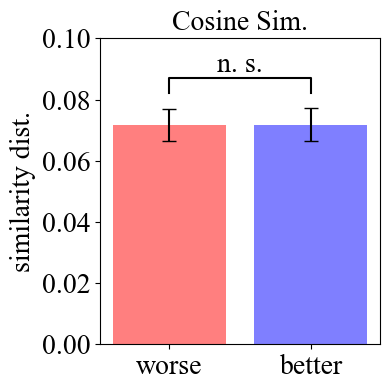

In [34]:
def barplot_annotate_brackets(num1, num2, data, center, 
                              height, yerr=None, dh=.05, 
                              barh=.05, fs=None, maxasterix=None):
    """ 
    Annotate barplot with p-values.
  
    :param num1: number of left bar to put bracket over
    :param num2: number of right bar to put bracket over
    :param data: string to write or number for generating asterixes
    :param center: centers of all bars (like plt.bar() input)
    :param height: heights of all bars (like plt.bar() input)
    :param yerr: yerrs of all bars (like plt.bar() input)
    :param dh: height offset over bar / bar + yerr in axes coordinates (0 to 1)
    :param barh: bar height in axes coordinates (0 to 1)
    :param fs: font size
    :param maxasterix: maximum number of asterixes to write (for very small p-values)
    """
  
    if type(data) is str:
        text = data
    else:
        # * is p < 0.05
        # ** is p < 0.005
        # *** is p < 0.0005
        # ↓↓↓↓↓↓↓↓↓↓↓
        # * is p < 0.05
        # ** is p < 0.01
        # *** is p < 0.001
        # etc.
        text = ''
        p = .05

        if data >= 0.1:
            text = 'n. s.'
        elif data < 0.1 and data >= 0.05:
            text = '†'
        elif data < 0.05 and data >= 0.01:
            text = '*'
        elif data < 0.01 and data >= 0.001:
            text = '**'
        elif data < 0.001:
            text = '***'
        
  
    lx, ly = center[num1], height[num1]
    rx, ry = center[num2], height[num2]
  
    if yerr:
        ly += yerr[num1]
        ry += yerr[num2]
  
    ax_y0, ax_y1 = plt.gca().get_ylim()
    dh *= (ax_y1 - ax_y0)
    barh *= (ax_y1 - ax_y0)
  
    y = max(ly, ry) + dh
  
    barx = [lx, lx, rx, rx]
    bary = [y, y+barh, y+barh, y]
    mid = ((lx+rx)/2, y+barh)
  
    plt.plot(barx, bary, c='black')
  
    kwargs = dict(ha='center', va='bottom')
    if fs is not None:
        kwargs['fontsize'] = fs
  
    plt.text(*mid, text, **kwargs, fontproperties=font_prop, fontsize=20)
    
    #ボックス作成
    pos = plt.gca().get_position()
    s_text = "n. s. : not significant\n† : p < 0.1\n* : p < 0.05\n** : p < 0.01\n*** : p < 0.001"
    dic_box = {
        'facecolor' : 'whitesmoke',
        'edgecolor' : 'black',
        'linewidth' : 1
    }

    #文字とボックスの挿入
    # plt.text(pos.x1+1.5, pos.y1-.7, s=s_text, 
    #         color='black', ha='center', fontsize='13', 
    #         bbox=dic_box)
   
""" main """
id = 0
n = 300
# Generate toy data
x0 = worse_cos_ar[id:n]
x1 = better_cos_ar[id:n]

# Welch’s t-test       
t01_value, p01_value = stats.ttest_ind(x0,x1,alternative='greater')
print("p01_value =", p01_value)
""" plot """

heights = [np.mean(x0), np.mean(x1)]
std = [np.std(x0)/np.sqrt(n), np.std(x1)/np.sqrt(n)]
label = ["worse", "better"]
width = 0.8 # the width of the bars
bars = np.arange(len(heights))
colors = ["red", "blue"]

plt.figure(figsize=(4, 4))
plt.title("Cosine Sim.", fontproperties=font_prop, fontsize=20)
plt.bar(bars, heights, width, yerr=std, color=colors,
        align='center', alpha=0.5, ecolor='black', capsize=5)
plt.xticks(bars, label, fontproperties=font_prop, fontsize=20)
plt.yticks(fontproperties=font_prop, fontsize=20)
plt.ylim(0,0.1)
plt.ylabel("similarity dist.",fontsize=20, fontproperties=font_prop)
barplot_annotate_brackets(0, 1, p01_value, bars,
                          heights, yerr=std)
plt.tight_layout()
# plt.savefig("../Figure/cossim.eps")

plt.show()


TtestResult(statistic=0.48688445840779865, pvalue=0.3132593091135929, df=598.0)


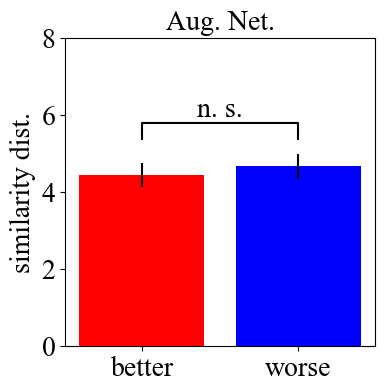

In [33]:
def barplot_annotate_brackets(num1, num2, data, center, 
                              height, yerr=None, dh=.05, 
                              barh=.05, fs=None, maxasterix=None):
    """ 
    Annotate barplot with p-values.
  
    :param num1: number of left bar to put bracket over
    :param num2: number of right bar to put bracket over
    :param data: string to write or number for generating asterixes
    :param center: centers of all bars (like plt.bar() input)
    :param height: heights of all bars (like plt.bar() input)
    :param yerr: yerrs of all bars (like plt.bar() input)
    :param dh: height offset over bar / bar + yerr in axes coordinates (0 to 1)
    :param barh: bar height in axes coordinates (0 to 1)
    :param fs: font size
    :param maxasterix: maximum number of asterixes to write (for very small p-values)
    """
  
    if type(data) is str:
        text = data
    else:
        # * is p < 0.05
        # ** is p < 0.005
        # *** is p < 0.0005
        # ↓↓↓↓↓↓↓↓↓↓↓
        # * is p < 0.05
        # ** is p < 0.01
        # *** is p < 0.001
        # etc.
        text = ''
        p = .05

        if data >= 0.1:
            text = 'n. s.'
        elif data < 0.1 and data >= 0.05:
            text = '†'
        elif data < 0.05 and data >= 0.01:
            text = '*'
        elif data < 0.01 and data >= 0.001:
            text = '**'
        elif data < 0.001:
            text = '***'
        
  
    lx, ly = center[num1], height[num1]
    rx, ry = center[num2], height[num2]
  
    if yerr:
        ly += yerr[num1]
        ry += yerr[num2]
  
    ax_y0, ax_y1 = plt.gca().get_ylim()
    dh *= (ax_y1 - ax_y0)
    barh *= (ax_y1 - ax_y0)
  
    y = max(ly, ry) + dh
  
    barx = [lx, lx, rx, rx]
    bary = [y, y+barh, y+barh, y]
    mid = ((lx+rx)/2, y+barh)
  
    plt.plot(barx, bary, c='black')
  
    kwargs = dict(ha='center', va='bottom')
    if fs is not None:
        kwargs['fontsize'] = fs
  
    plt.text(*mid, text, **kwargs, fontproperties=font_prop, fontsize=20)
    
    #ボックス作成
    pos = plt.gca().get_position()
    s_text = "n. s. : not significant\n† : p < 0.1\n* : p < 0.05\n** : p < 0.01\n*** : p < 0.001"
    dic_box = {
        'facecolor' : 'whitesmoke',
        'edgecolor' : 'black',
        'linewidth' : 1
    }

    #文字とボックスの挿入
    # plt.text(pos.x1+1.3, pos.y1+11, s=s_text, 
    #         color='black', ha='center', fontsize='13', 
    #         bbox=dic_box)

id = 0
n = 300
# Generate toy data
x1 = worse_dist_ar[id:n]
x0 = better_dist_ar[id:n]

# Welch’s t-test       
t01_value, p01_value = stats.ttest_ind(x0,x1,alternative='less') 
 
""" plot """
heights = [np.mean(x0), np.mean(x1)]
std = [np.std(x0)/np.sqrt(n), np.std(x1)/np.sqrt(n)]
label = ["better", "worse"]
width = 0.8 # the width of the bars
bars = np.arange(len(heights))
colors = ["red", "blue"]

plt.figure(figsize=(4, 4))
plt.bar([0], [np.mean(x0)],yerr=np.std(x0)/np.sqrt(n),color="red")
plt.bar([1], [np.mean(x1)],yerr=np.std(x1)/np.sqrt(n),color="blue")
plt.xticks([0,1],["better","worse"], fontproperties=font_prop, fontsize=20)
plt.ylim(0, 8)
plt.yticks([0,2,4,6,8], fontproperties=font_prop, fontsize=20)
plt.ylabel("similarity dist.", fontproperties=font_prop, fontsize=20)
plt.title("Aug. Net.", fontproperties=font_prop, fontsize=20)

barplot_annotate_brackets(0, 1, p01_value, bars,
                          heights, yerr=std)

# plt.savefig("../Figure/augnet.eps")

test1 = stats.ttest_ind(x1,x0,alternative='greater')
print(test1)
